**REMEMBER WE ONLY HAVE 100 ROWS OF DATA 80 ARE FOR TRAINING AND 20 FOR TESTING SO DO NOT EXPECT TO HAVE VERY HIGH ACCURACY RESULTS UNLESS YOU GENERATED ADDITIONAL RANDOM DATASETS BASED ON MEAN AND MEDIANS TO EXTEND THE DATA SET SIZE **

In [6]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # imported library to use boxcox because logX alone wasnt that good
import pickle
#from sklearn.model_selection import train_test_split
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------
# 1️⃣ Core libraries
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# 2️⃣ Preprocessing
# ------------------------------
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# ------------------------------
# 3️⃣ Regression models
# ------------------------------
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ------------------------------
# 4️⃣ Metrics
# ------------------------------
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
df = pd.read_csv("WinePricePredictionP1/WINE_PRICE.csv")


In [8]:
df

,Fixed_Acidity,Volatile_Acidity,Citric_Acid,Residual_Sugar,Chlorides,Free_Sulfur_Dioxide,Total_Sulfur_Dioxide,Density,pH,Alcohol,Price
0,8.99,0.22,0.92,2.51,0.018,39,125,0.9923,3.10,11.05,42.87
1,7.72,0.42,0.80,3.32,0.038,49,138,0.9938,3.09,9.91,36.30
2,9.30,0.43,0.98,7.24,0.050,16,56,0.9969,3.04,10.54,37.86
3,11.05,0.34,1.16,6.83,0.051,35,120,0.9961,2.92,12.42,43.61
4,7.53,0.47,0.68,4.94,0.041,23,74,0.9942,3.10,10.79,36.46
...,...,...,...,...,...,...,...,...,...,...,...
95,5.07,0.58,0.47,3.59,0.061,24,71,0.9941,3.28,10.08,30.14
96,8.59,0.32,0.90,-0.14,0.029,27,85,0.9898,3.06,13.20,44.60
97,8.52,0.53,0.87,9.06,0.046,20,48,0.9994,3.08,11.46,34.09
98,8.01,0.51,0.84,4.66,0.032,25,85,0.9947,3.16,9.64,35.26


In [9]:
df.shape #ti know rows and columns

(100, 11)

In [10]:
df.columns#to see column names

Index(['Fixed_Acidity', 'Volatile_Acidity', 'Citric_Acid', 'Residual_Sugar',
       'Chlorides', 'Free_Sulfur_Dioxide', 'Total_Sulfur_Dioxide', 'Density',
       'pH', 'Alcohol', 'Price'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fixed_Acidity         100 non-null    float64
 1   Volatile_Acidity      100 non-null    float64
 2   Citric_Acid           100 non-null    float64
 3   Residual_Sugar        100 non-null    float64
 4   Chlorides             100 non-null    float64
 5   Free_Sulfur_Dioxide   100 non-null    int64  
 6   Total_Sulfur_Dioxide  100 non-null    int64  
 7   Density               100 non-null    float64
 8   pH                    100 non-null    float64
 9   Alcohol               100 non-null    float64
 10  Price                 100 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 8.7 KB


In [12]:
df.isnull().sum()

Fixed_Acidity           0
Volatile_Acidity        0
Citric_Acid             0
Residual_Sugar          0
Chlorides               0
Free_Sulfur_Dioxide     0
Total_Sulfur_Dioxide    0
Density                 0
pH                      0
Alcohol                 0
Price                   0
dtype: int64

In [13]:
df.describe()

,Fixed_Acidity,Volatile_Acidity,Citric_Acid,Residual_Sugar,Chlorides,Free_Sulfur_Dioxide,Total_Sulfur_Dioxide,Density,pH,Alcohol,Price
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,7.792000,0.571300,0.782300,5.320600,0.048840,28.3300,86.270000,0.995316,3.121800,10.869900,36.639900
std,1.816701,0.388779,0.199235,2.652322,0.021277,9.2475,28.887401,0.002658,0.106471,2.099639,10.236003
min,2.760000,0.120000,0.230000,-1.370000,0.004000,5.0000,7.000000,0.988800,2.870000,6.860000,16.770000
25%,6.800000,0.340000,0.660000,3.300000,0.031750,23.0000,72.750000,0.993575,3.040000,9.647500,32.497500
50%,7.745000,0.515000,0.790000,5.150000,0.048500,28.5000,86.000000,0.995400,3.120000,10.695000,35.480000
75%,8.810000,0.630000,0.912500,7.055000,0.063000,35.0000,104.500000,0.997100,3.200000,11.625000,39.227500
max,11.700000,2.590000,1.210000,11.570000,0.112000,52.0000,163.000000,1.001800,3.360000,18.600000,80.870000


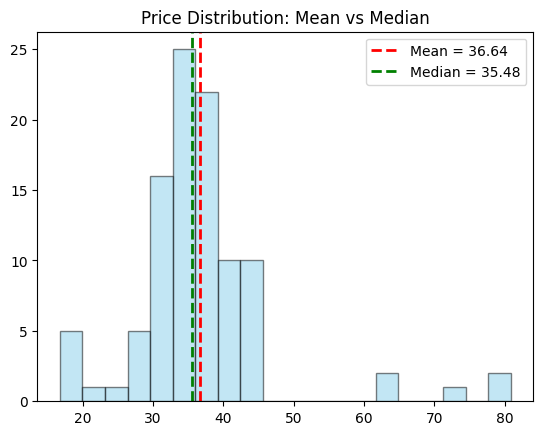

In [14]:
import matplotlib.pyplot as plt

col = 'Price'  # example column

plt.hist(df[col], bins=20, alpha=0.5, color='skyblue', edgecolor='black')
plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean = {df[col].mean():.2f}")
plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2, label=f"Median = {df[col].median():.2f}")
plt.legend()
plt.title(f"{col} Distribution: Mean vs Median")
plt.show()

#What you see
#Red dashed line = mean
#Green dashed line = median
#If lines overlap → symmetric
#If lines separated → skewed

In [15]:
#how can I know which column is the cause of all these Skews ??

# Calculate mean, median, skew for all columns
summary = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Skew': df.skew()
})
print(summary)

                           Mean   Median      Skew
Fixed_Acidity          7.792000   7.7450 -0.178238
Volatile_Acidity       0.571300   0.5150  3.075366
Citric_Acid            0.782300   0.7900 -0.205742
Residual_Sugar         5.320600   5.1500  0.200034
Chlorides              0.048840   0.0485  0.267151
Free_Sulfur_Dioxide   28.330000  28.5000 -0.031829
Total_Sulfur_Dioxide  86.270000  86.0000 -0.318598
Density                0.995316   0.9954  0.194917
pH                     3.121800   3.1200  0.024997
Alcohol               10.869900  10.6950  1.384602
Price                 36.639900  35.4800  2.060701


--- Outlier Analysis for Volatile_Acidity ---
Number of outliers: 5
    Volatile_Acidity  Price
13              2.59  17.38
61              2.26  17.41
75              1.88  16.77
94              1.77  18.17
5               1.60  18.21


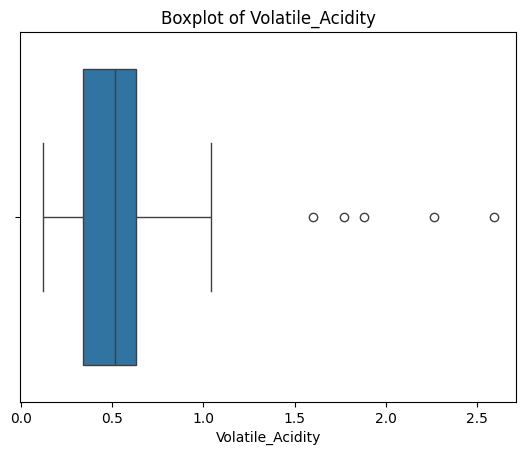

--- Outlier Analysis for Alcohol ---
Number of outliers: 5
    Alcohol  Price
34    18.60  63.39
56    18.56  79.88
38    17.49  80.87
59    16.62  73.27
74    15.57  63.70


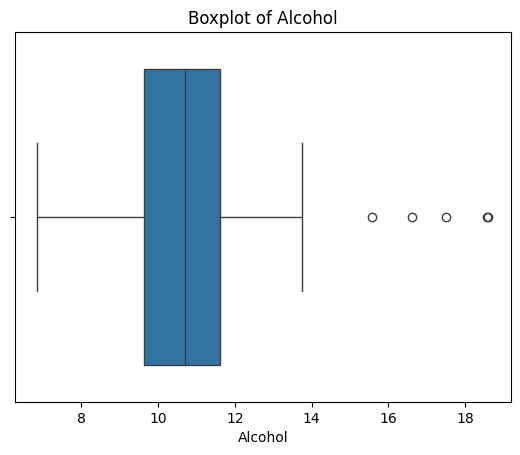

In [16]:
#we are checking whether outliers are rare values or real outliers
# List of columns to check
columns = ['Volatile_Acidity', 'Alcohol']

for col in columns:
    print(f"--- Outlier Analysis for {col} ---")

    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print("Number of outliers:", len(outliers))
    print(outliers[[col, 'Price']].sort_values(col, ascending=False))

    # Plot boxplot
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()  # Ensures each plot shows in Colab

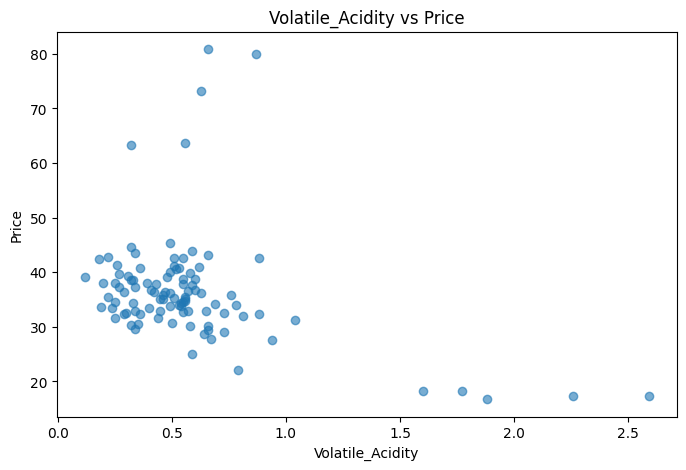

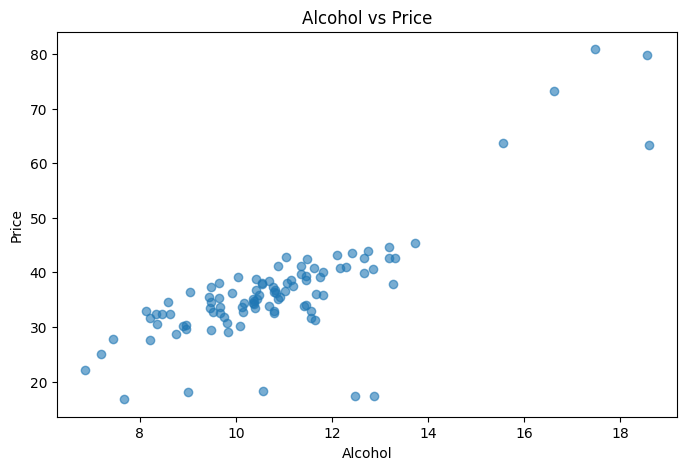

In [17]:
#we are checking whether outliers are rare values or real outliers
# List of columns to check
columns = ['Volatile_Acidity', 'Alcohol']

for col in columns:
    plt.figure(figsize=(8,5))
    plt.scatter(df[col], df['Price'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.title(f"{col} vs Price")
    plt.show()  # Makes sure each scatter plot shows in Colab

In [18]:
#managing skewed data
df['Volatile_Acidity_log'] = np.log1p(df['Volatile_Acidity']) #log since its a right skew also for left skew we can use log
df['Alcohol_log'] = np.log1p(df['Alcohol'])


In [19]:
#checking skews after fixing
df[['Volatile_Acidity_log','Alcohol_log']].skew()

Volatile_Acidity_log    1.988208
Alcohol_log             0.580092
dtype: float64

<Axes: xlabel='Volatile_Acidity_log', ylabel='Count'>

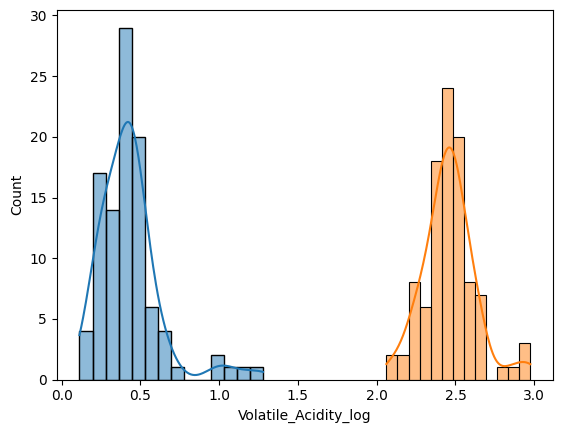

In [20]:
#checking skews after fixing
import seaborn as sns
sns.histplot(df['Volatile_Acidity_log'], kde=True)
sns.histplot(df['Alcohol_log'], kde=True)

In [21]:

# Volatile_Acidity must be strictly positive
df['Volatile_Acidity_log_boxcox'], _ = stats.boxcox(df['Volatile_Acidity_log'] + 1e-6)  # add tiny value if zeros exist

Volatile_Acidity_log_boxcox   -0.005985
Alcohol_log                    0.580092
dtype: float64


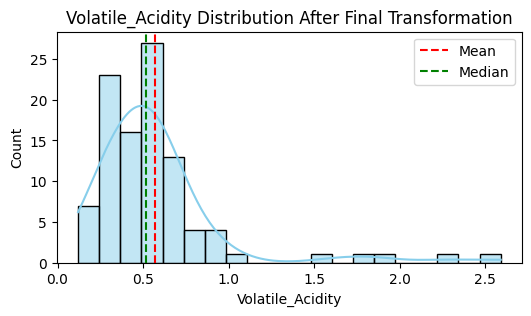

In [22]:
print(df[['Volatile_Acidity_log_boxcox','Alcohol_log']].skew())

import matplotlib.pyplot as plt
import seaborn as sns

for col in ['Volatile_Acidity']:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.axvline(df[col].mean(), color='red', linestyle='dashed', label='Mean')
    plt.axvline(df[col].median(), color='green', linestyle='dashed', label='Median')
    plt.legend()
    plt.title(f'{col} Distribution After Final Transformation')
    plt.show()

REMARK !!!!
I COULD HAVE REMOVED LOGX ON VOLATILE ACIDITY AND SIMPLY USE COXBOX IT WILL DIRECTLY GIVE GOOD RESULTS

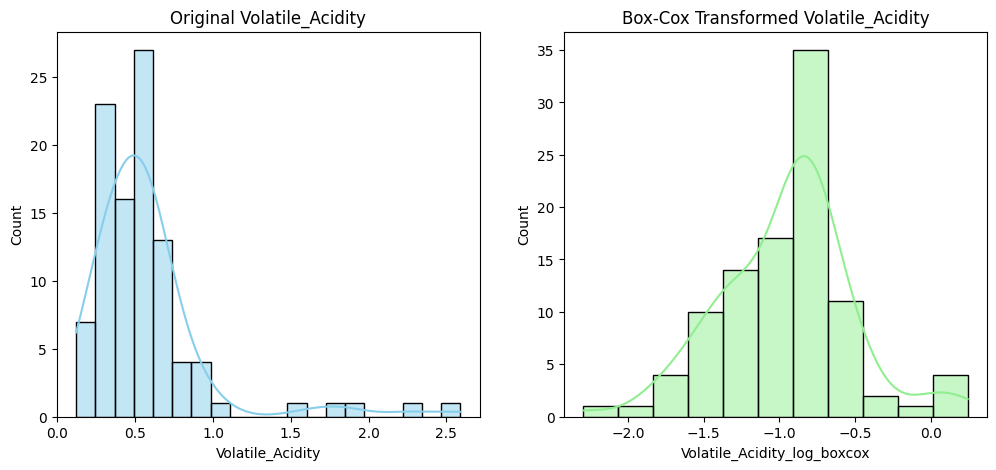

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Volatile_Acidity'], kde=True, color='skyblue')
plt.title('Original Volatile_Acidity')

plt.subplot(1,2,2)
sns.histplot(df['Volatile_Acidity_log_boxcox'], kde=True, color='lightgreen')
plt.title('Box-Cox Transformed Volatile_Acidity')

plt.show()

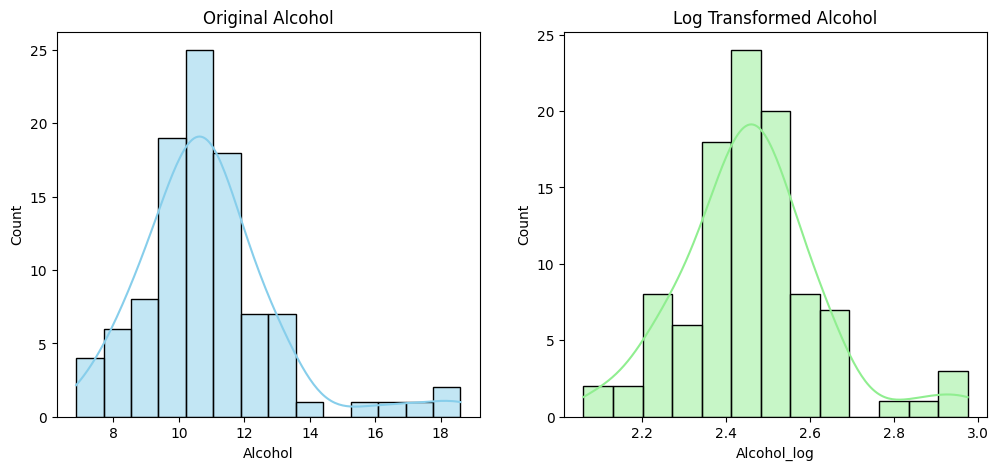

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['Alcohol'], kde=True, color='skyblue')
plt.title('Original Alcohol')

plt.subplot(1,2,2)
sns.histplot(df['Alcohol_log'], kde=True, color='lightgreen')
plt.title('Log Transformed Alcohol')

plt.show()

In [25]:
# Compute correlations with target
corr_target = df.corr()['Price'].sort_values(ascending=False)
print(corr_target)

Price                          1.000000
Alcohol                        0.801708
Alcohol_log                    0.759652
Citric_Acid                    0.125626
Fixed_Acidity                  0.081051
Density                        0.040993
Free_Sulfur_Dioxide            0.032490
Residual_Sugar                -0.001532
Total_Sulfur_Dioxide          -0.015721
pH                            -0.129447
Chlorides                     -0.183169
Volatile_Acidity_log_boxcox   -0.224806
Volatile_Acidity_log          -0.322727
Volatile_Acidity              -0.360294
Name: Price, dtype: float64


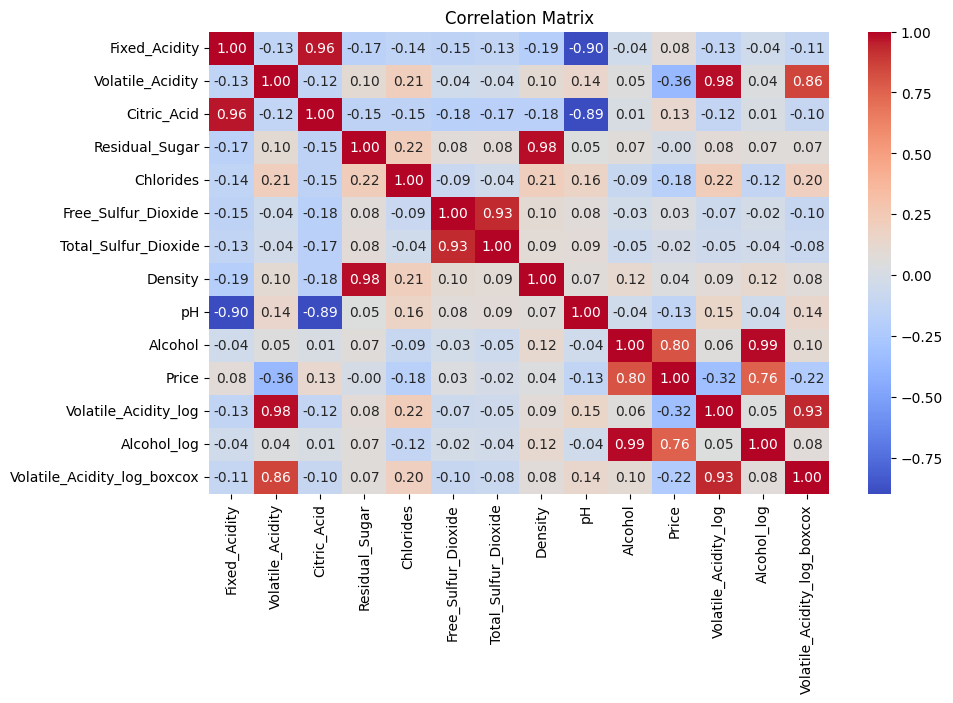

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

| Feature                                 | Correlation           | Interpretation                                      |
| --------------------------------------- | --------------------- | --------------------------------------------------- |
| **Alcohol / Alcohol_log**               | 0.8017 / 0.7597       | Strong positive → keep                              |
| **Volatile_Acidity / log / log_boxcox** | -0.36 / -0.32 / -0.22 | Strong negative → keep                              |
| Citric_Acid                             | 0.1256                | Very weak → minor effect                            |
| Fixed_Acidity                           | 0.0811                | Almost zero → negligible                            |
| Density                                 | 0.0410                | Almost zero → negligible                            |
| Free_Sulfur_Dioxide                     | 0.0325                | Almost zero → negligible                            |
| Residual_Sugar                          | -0.0015               | Zero correlation → useless for linear relationships |
| Total_Sulfur_Dioxide                    | -0.0157               | Almost zero → negligible                            |
| pH                                      | -0.1294               | Weak → minor effect                                 |
| Chlorides                               | -0.1832               | Weak negative → minor effect                        |


In [27]:
print(df)

    Fixed_Acidity  Volatile_Acidity  Citric_Acid  Residual_Sugar  Chlorides  \
0            8.99              0.22         0.92            2.51      0.018   
1            7.72              0.42         0.80            3.32      0.038   
2            9.30              0.43         0.98            7.24      0.050   
3           11.05              0.34         1.16            6.83      0.051   
4            7.53              0.47         0.68            4.94      0.041   
..            ...               ...          ...             ...        ...   
95           5.07              0.58         0.47            3.59      0.061   
96           8.59              0.32         0.90           -0.14      0.029   
97           8.52              0.53         0.87            9.06      0.046   
98           8.01              0.51         0.84            4.66      0.032   
99           7.53              0.27         0.78            8.71      0.022   

    Free_Sulfur_Dioxide  Total_Sulfur_Dioxide  Dens

In [28]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

In [29]:
print(df.columns)

Index(['Fixed_Acidity', 'Volatile_Acidity', 'Citric_Acid', 'Residual_Sugar',
       'Chlorides', 'Free_Sulfur_Dioxide', 'Total_Sulfur_Dioxide', 'Density',
       'pH', 'Alcohol', 'Price', 'Volatile_Acidity_log', 'Alcohol_log',
       'Volatile_Acidity_log_boxcox'],
      dtype='object')


In [30]:
# Drop raw Alcohol and Volatile_Acidity
df = df.drop(columns=['Alcohol', 'Volatile_Acidity','Volatile_Acidity_log'])
# Keep: Alcohol_log and Volatile_Acidity_log_boxcox

In [31]:
print(df.columns)

Index(['Fixed_Acidity', 'Citric_Acid', 'Residual_Sugar', 'Chlorides',
       'Free_Sulfur_Dioxide', 'Total_Sulfur_Dioxide', 'Density', 'pH', 'Price',
       'Alcohol_log', 'Volatile_Acidity_log_boxcox'],
      dtype='object')


In [32]:
# Ratios
df['Sulfur_Ratio'] = df['Free_Sulfur_Dioxide'] / (df['Total_Sulfur_Dioxide'] + 1e-6)
df['Sugar_Acidity_Ratio'] = df['Residual_Sugar'] / (df['Fixed_Acidity'] + 1e-6)
df['Alcohol_to_Acidity'] = df['Alcohol_log'] / (df['Fixed_Acidity'] + 1e-6)
df['Volatile_to_Fixed_Acidity'] = df['Volatile_Acidity_log_boxcox'] / (df['Fixed_Acidity'] + 1e-6)

# Interactions
df['Alcohol_x_CitricAcid'] = df['Alcohol_log'] * df['Citric_Acid']
df['ResidualSugar_x_Alcohol'] = df['Residual_Sugar'] * df['Alcohol_log']

# Transformations
df['Residual_Sugar_log'] = np.log1p(df['Residual_Sugar'])
df['pH_squared'] = df['pH']**2

c:\Users\army\anaconda3\envs\wine_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [33]:
# Compute correlation matrix
corr_matrix = df.corr()

# Correlation of all features with Price
corr_with_price = corr_matrix['Price'].sort_values(ascending=False)
print(corr_with_price)

Price                          1.000000
Alcohol_log                    0.759652
Alcohol_x_CitricAcid           0.305322
Alcohol_to_Acidity             0.184835
Citric_Acid                    0.125626
ResidualSugar_x_Alcohol        0.101794
Sugar_Acidity_Ratio            0.083781
Fixed_Acidity                  0.081051
Density                        0.040993
Free_Sulfur_Dioxide            0.032490
Residual_Sugar                -0.001532
Sulfur_Ratio                  -0.003621
Residual_Sugar_log            -0.010873
Total_Sulfur_Dioxide          -0.015721
pH_squared                    -0.126687
pH                            -0.129447
Chlorides                     -0.183169
Volatile_to_Fixed_Acidity     -0.210253
Volatile_Acidity_log_boxcox   -0.224806
Name: Price, dtype: float64


In [34]:
#Random Forest will automatically assign near-zero importance
#to useless features, so dropping them is optional.
df = df.drop(columns=[
    'Residual_Sugar',
    'Sugar_Acidity_Ratio',
    'Fixed_Acidity',
    'Sulfur_Ratio',
    'Residual_Sugar_log',
    'Total_Sulfur_Dioxide',
    'Density',
    'Free_Sulfur_Dioxide'
])

In [35]:
print(df.columns)

Index(['Citric_Acid', 'Chlorides', 'pH', 'Price', 'Alcohol_log',
       'Volatile_Acidity_log_boxcox', 'Alcohol_to_Acidity',
       'Volatile_to_Fixed_Acidity', 'Alcohol_x_CitricAcid',
       'ResidualSugar_x_Alcohol', 'pH_squared'],
      dtype='object')


In [36]:
# Check min, max, mean, std for all features to see if scaling is needed
#BUT RANDOM FOREST DOESNT REQUIRE SCALING!!!!
#df.describe()

#BUT IF I WANT TO SCALE THEN
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(df.drop(columns='Price'))

In [37]:
#If you set random_state to a fixed number (like 42),
#every time you run this code, you will get exactly the same split of data into training
#and testing sets.
#If you don’t set it or set it to None,
#the split will be random each time you run the code,
#so your train/test sets will be different each time.

# Features (drop target)
#X = df.drop(columns='Price')

# Target
#y = df['Price']

# Train-test split (e.g., 80% train, 20% test)
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42
#)

#print("Train shape:", X_train.shape)
#print("Test shape:", X_test.shape)

In [38]:
# =========================================
# 4️⃣ Initialize and train Random Forest
# =========================================
#rf = RandomForestRegressor(
#    n_estimators=100,   # number of trees
#    max_depth=None,     # allow full growth
#    random_state=42
#)

#rf.fit(X_train, y_train)

In [39]:
# =========================================
# 5️⃣ Make predictions
# =========================================
#y_pred = rf.predict(X_test)

In [40]:
# =========================================
# 6️⃣ Evaluate model
# =========================================
#mse = mean_squared_error(y_test, y_pred)
#rmse = mse**0.5
#r2 = r2_score(y_test, y_pred)

#print(f"RMSE: {rmse:.2f}")
#print(f"R^2: {r2:.2f}")


In [41]:
# =========================================
# 7️⃣ Feature importance
# =========================================
#importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)


In [42]:
# Plot feature importance
#plt.figure(figsize=(12,6))
#importances.plot(kind='bar')
#plt.title("Random Forest Feature Importance")
#plt.ylabel("Importance")
#plt.show()

# Optional: see top 10 features
#print("Top 10 features by importance:")
#print(importances.head(10))

In [43]:
# Original features
X = df.drop(columns=['Price'])
y = df['Price']

# 1️⃣ Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2️⃣ Convert scaled array back to DataFrame to keep column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 3️⃣ Check the first few rows to see scaled values
print(X_scaled_df.head())

# 4️⃣ Train-test split for scaled models
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

   Citric_Acid  Chlorides        pH  Alcohol_log  Volatile_Acidity_log_boxcox  \
0     0.694625  -1.456770 -0.205782     0.176622                    -1.672926   
1     0.089287  -0.512042 -0.300177    -0.424826                    -0.271950   
2     0.997294   0.054794 -0.772153    -0.085087                    -0.223699   
3     1.905300   0.102031 -1.904896     0.828278                    -0.714253   
4    -0.516050  -0.370333 -0.205782     0.044616                    -0.043177   

   Alcohol_to_Acidity  Volatile_to_Fixed_Acidity  Alcohol_x_CitricAcid  \
0           -0.543110                  -0.877772              0.703488   
1           -0.254759                  -0.159111             -0.024871   
2           -0.665595                   0.231784              0.909486   
3           -0.912627                   0.213432              2.094524   
4           -0.094915                  -0.014151             -0.475552   

   ResidualSugar_x_Alcohol  pH_squared  
0                -1.042283 

              Model      RMSE        R2  CV_R2_mean
0      RandomForest  3.144797  0.681437    0.865350
1  GradientBoosting  3.232231  0.663477    0.861698
2      DecisionTree  3.546364  0.594887    0.835446
3  LinearRegression  7.415139 -0.771122    0.520738
5             Lasso  3.122445  0.685949    0.513896
4             Ridge  4.993645  0.196760    0.441743
7               KNN  4.081782  0.463327    0.310308
6               SVR  3.820767  0.529769    0.142360


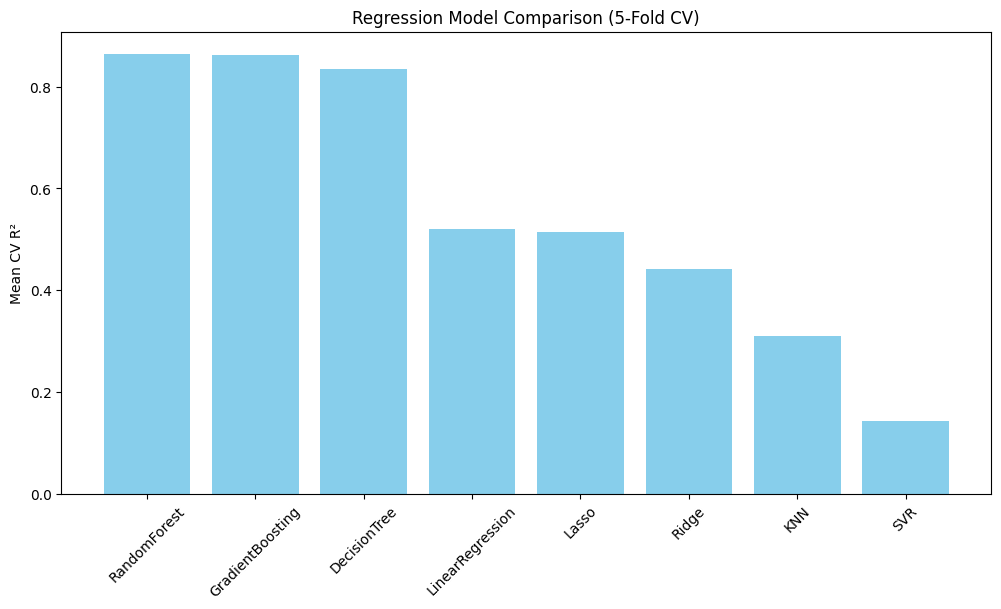


RandomForest Feature Importance:
 Alcohol_log                    0.747988
Volatile_to_Fixed_Acidity      0.102590
Volatile_Acidity_log_boxcox    0.087277
Alcohol_x_CitricAcid           0.018311
pH                             0.008448
ResidualSugar_x_Alcohol        0.008251
Chlorides                      0.008249
pH_squared                     0.007983
Alcohol_to_Acidity             0.005943
Citric_Acid                    0.004959
dtype: float64

GradientBoosting Feature Importance:
 Alcohol_log                    0.760759
Volatile_Acidity_log_boxcox    0.127974
Volatile_to_Fixed_Acidity      0.073529
Alcohol_x_CitricAcid           0.020655
Chlorides                      0.004369
pH                             0.004123
ResidualSugar_x_Alcohol        0.003471
pH_squared                     0.002847
Alcohol_to_Acidity             0.001293
Citric_Acid                    0.000980
dtype: float64

DecisionTree Feature Importance:
 Alcohol_log                    0.772669
Volatile_to_Fixed_Aci

In [44]:
# =============================
# 1️⃣ Prepare Data
# =============================

# X = all features except the target 'Price'
# df.drop(columns=['Price']) removes the 'Price' column from the DataFrame
# This is our feature matrix for training the models
X = df.drop(columns=['Price'])

# y = target variable, the column we want to predict
# Here it's the Price of wine
# Optional: if Price is highly skewed, you could use log-transform:
# y = np.log1p(df['Price']) to stabilize variance
y = df['Price']

# =============================
# 2️⃣ Scale features for certain models
# =============================

# Initialize a StandardScaler object
# StandardScaler removes the mean and scales each feature to unit variance
# (mean=0, std=1)
scaler = StandardScaler()

# Fit the scaler to X and transform it
# fit_transform learns the mean & std from X and applies scaling
# Returns a NumPy array (column names lost here)
X_scaled = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
# Keep the original column names using columns=X.columns
# Now X_scaled_df has the same feature names but scaled values
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# -----------------------------
# Train-test split
# -----------------------------

# Split unscaled features for tree-based models
# Random state 42 ensures reproducibility (same split every run)
# test_size=0.2 → 20% of data goes to testing (here 20 rows out of 100)
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split scaled features for models that need scaling (Linear, Ridge, Lasso, KNN, SVR)
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42
)

# =============================
# 3️⃣ Define models and scaling requirement
# =============================

# Dictionary of models and whether they need scaled features or not
# Key = model name (string)
# Value = tuple of (model instance, 'scaled' or 'tree')
models = {
    # RandomForestRegressor → tree-based, does not require scaling
    # n_estimators=500 → number of trees, more trees → more stable predictions
    "RandomForest": (RandomForestRegressor(random_state=42, n_estimators=500), "tree"),

    # GradientBoostingRegressor → tree-based, boosting ensemble, also doesn't require scaling
    "GradientBoosting": (GradientBoostingRegressor(random_state=42, n_estimators=500), "tree"),

    # DecisionTreeRegressor → single tree, tree-based
    "DecisionTree": (DecisionTreeRegressor(random_state=42), "tree"),

    # LinearRegression → needs scaled features for best performance
    "LinearRegression": (LinearRegression(), "scaled"),

    # Ridge → linear regression with L2 regularization, scaled features
    "Ridge": (Ridge(), "scaled"),

    # Lasso → linear regression with L1 regularization, scaled features
    "Lasso": (Lasso(), "scaled"),

    # SVR → Support Vector Regressor, highly sensitive to feature scale
    "SVR": (SVR(), "scaled"),

    # KNN → distance-based, sensitive to scale, needs scaling
    "KNN": (KNeighborsRegressor(), "scaled")
}

# =============================
# 4️⃣ Train, predict, evaluate
# =============================

# Initialize empty list to store results for each model
results = []

# Loop through all models
for name, (model, scale_type) in models.items():

    # Select proper X depending on whether the model needs scaled data
    if scale_type == 'scaled':
        # Use the scaled features
        X_tr, X_te, y_tr, y_te = X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled
    else:
        # Use unscaled features for tree-based models
        X_tr, X_te, y_tr, y_te = X_train_tree, X_test_tree, y_train_tree, y_test_tree

    # -----------------------------
    # Train the model
    # -----------------------------
    # Fit the model on training data
    # model learns patterns from X_tr to predict y_tr
    model.fit(X_tr, y_tr)

    # -----------------------------
    # Predict on test set
    # -----------------------------
    # model predicts Price (or y) for unseen test data X_te
    y_pred = model.predict(X_te)

    # -----------------------------
    # Compute metrics
    # -----------------------------
    # Mean Squared Error → average squared difference between predicted and actual
    mse = mean_squared_error(y_te, y_pred)

    # RMSE → square root of MSE, same units as target (Price)
    rmse = np.sqrt(mse)

    # R² score → proportion of variance explained by the model
    # 1 = perfect, 0 = predicts mean, negative = worse than mean
    r2 = r2_score(y_te, y_pred)

    # Cross-validated R² → average R² on 5 folds of training data
    # Ensures the model generalizes well and is not overfitting
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    # Append metrics for this model to results list
    results.append({
        "Model": name,
        "RMSE": rmse,                     # Test RMSE
        "R2": r2,                         # Test R²
        "CV_R2_mean": cv_scores.mean()    # Average CV R²
    })

# =============================
# 5️⃣ Results DataFrame & Plot
# =============================

# Convert results list to DataFrame
# Sort by CV_R2_mean descending → best performing model first
results_df = pd.DataFrame(results).sort_values(by="CV_R2_mean", ascending=False)

# Print the results table
print(results_df)

# Plot bar chart of mean CV R² for all models
plt.figure(figsize=(12,6))                      # Figure size
plt.bar(results_df['Model'], results_df['CV_R2_mean'], color='skyblue')  # Bar chart
plt.ylabel("Mean CV R²")                        # Y-axis label
plt.title("Regression Model Comparison (5-Fold CV)")  # Chart title
plt.xticks(rotation=45)                          # Rotate X labels for readability
plt.show()

# =============================
# 6️⃣ Optional: Feature importance for tree-based models
# =============================

# Loop through models to show feature importance only for tree-based models
for name, (model, scale_type) in models.items():
    if scale_type == 'tree':  # Only for RandomForest, GradientBoosting, DecisionTree
        # Get feature importance as a Series, indexed by column names
        feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

        # Print feature importance for this model
        print(f"\n{name} Feature Importance:\n", feat_imp)

The below ensures:

Correct column order
No missing columns
No extra columns

In [45]:
with open('rf_features.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

In [46]:
with open('rf_features.pkl', 'rb') as f:
    feature_names = pickle.load(f)

In [47]:
print(feature_names)

['Citric_Acid', 'Chlorides', 'pH', 'Alcohol_log', 'Volatile_Acidity_log_boxcox', 'Alcohol_to_Acidity', 'Volatile_to_Fixed_Acidity', 'Alcohol_x_CitricAcid', 'ResidualSugar_x_Alcohol', 'pH_squared']


In [48]:
# Pick the RandomForest model from your dictionary
rf_model = models['RandomForest'][0]  # models['RandomForest'] = (model_instance, "tree")

# Train it on the tree-based training data
rf_model.fit(X_train_tree, y_train_tree)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# Save the trained model
with open('randomforest_model.pkl', 'wb') as f:  # wb = write binary
    pickle.dump(rf_model, f)